<a href="https://colab.research.google.com/github/Yaaxek/TelecomX_LATAM/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Proyecto "Churn de Clientes".**

###La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

#📌 Extracción

In [727]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [728]:
import pandas as pd
import numpy as np

In [729]:
df=pd.read_json('/content/drive/MyDrive/TelecomX_LATAM/TelecomX_Data.json')
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformación

In [730]:
pd.options.display.max_info_columns

100

In [731]:
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

df = pd.concat([
    df[['customerID', 'Churn']],
    customer_df,
    phone_df,
    internet_df,
    account_df
], axis=1)


In [732]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [733]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [734]:
for col in df.select_dtypes(include='object').columns:
    vacios = df[col].isin(['', ' ', 'N/A', 'null', '-',',']).sum()
    caracteres = df[col].str.contains(r'[?,!;]', regex=True, na=False).sum()

    if vacios > 0:
        print(f"{col}: {vacios} valores vacíos")
    if caracteres > 0:
        print(f"{col}: {caracteres} valores con caracteres especiales")

for col in df.select_dtypes(exclude='object').columns:
    nulos = df[col].isna().sum()
    if nulos > 0:
        print(f"{col}: {nulos} valores nulos (NaN)")

Churn: 224 valores vacíos
Charges.Total: 11 valores vacíos


Se parte del supuesto que Charges.Total ≈ Charges.Monthly * tenure

Posiblemente el campo tenure es 0 (por ser cliente nuevo) y el resultado del calculo es aproximado , debido a que hay otras variaciones que no se han incluido en la data.

Los datos vacíos de Churn indican simplemente que no se sabe si el cliente continua o canceló su contrato por lo que se omitiran.

In [735]:
# Cambiar los valores vacios
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce').fillna(df['Charges.Monthly'] * df['tenure'])

# Las filas con valores nulos seran eliminadas para un mejor analisis
df = df[df['Churn'].isin(['Yes', 'No'])]


In [736]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [737]:
df.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [738]:
df = df.copy()

In [739]:
df.loc[:, 'Cuentas_Diarias'] = df['Charges.Monthly'] / 30
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


Se normalizara todos los Yes y No a numeros binarios (0 y 1).

Siendo 0: No

Siendo 1: Yes

In [740]:
df = df.replace('No internet service', 'No')
df = df.replace('No phone service', 'No')

In [741]:
df = df.replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   int64  
 5   Dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   int64  
 8   MultipleLines     7043 non-null   int64  
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   int64  
 11  OnlineBackup      7043 non-null   int64  
 12  DeviceProtection  7043 non-null   int64  
 13  TechSupport       7043 non-null   int64  
 14  StreamingTV       7043 non-null   int64  
 15  StreamingMovies   7043 non-null   int64  
 16  Contract          7043 non-null   object 
 17  

#📊 Carga y análisis


##**Análisis Descriptivo**

In [742]:
df.sample(4)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
587,0839-QNXME,0,Female,0,0,0,30,1,0,0,0,0,0,0,0,0,Two year,0,Credit card (automatic),19.40,578.50,0.646667
3667,5055-BRMNE,0,Female,0,1,1,67,1,1,Fiber optic,1,0,0,1,1,1,Two year,0,Credit card (automatic),106.70,7009.50,3.556667
4485,6145-NNPNO,0,Female,0,0,0,1,1,0,DSL,0,0,0,0,0,0,Month-to-month,0,Bank transfer (automatic),44.15,44.15,1.471667
4870,6656-JWRQX,0,Female,0,0,0,1,0,0,DSL,0,0,0,1,0,0,Month-to-month,0,Mailed check,30.55,30.55,1.018333


En todas las filas que tienen como valor min 0 y maximo 1, son las de verdadero y falso.

En ternure o Permanencia son los meses de permanencia con el servicio.

Podemos observar tambien el cargo mensual, total y diario sus promedios.

In [743]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [744]:
df.nunique()

,0
customerID,7043
Churn,2
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,2
InternetService,3


Obtenemos tambien los valores de object para saber:
Count: Total de registros (7043 en todas)

unique:Cantidad de valores diferentes

top: El valor que más se repite

freq: Cuántas veces aparece el top

In [745]:
df.describe(include='object')

,customerID,gender,InternetService,Contract,PaymentMethod
count,7043,7043,7043,7043,7043
unique,7043,2,3,3,4
top,9995-HOTOH,Male,Fiber optic,Month-to-month,Electronic check
freq,1,3555,3096,3875,2365


In [746]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
0,1526


### **INSIGHTS**

**1. Tasa de Churn preocupante**
El 26.5% de los clientes cancelaron. Esto significa que aproximadamente 1 de cada 4 clientes se va, lo cual es una señal de alerta para el negocio.

**2. Clientes poco comprometidos**
El tenure (permanencia) promedio es de 32 meses, pero el 25% de los clientes tiene menos de 9 meses. Por lo que no llegan ni al año.

**3. Servicios adicionales subutilizados**
Los servicios de protección se contratan menos que los de entretenimiento:

- **Protección (29-34%):** OnlineSecurity (29%), TechSupport (29%), DeviceProtection (34%), OnlineBackup (34%)
- **Entretenimiento (38-39%):** StreamingTV (38%), StreamingMovies (39%)

Los clientes priorizan entretenimiento sobre seguridad. Hay oportunidad de vender más servicios de protección, los cuales podrían generar mayor retención.

**4. Casi todos tienen teléfono (90%)**
PhoneService es casi universal, pero solo 42% tiene MultipleLines. El servicio base está cubierto, los adicionales no tanto.

**5. Rango de precios amplio**
Los cargos mensuales van de USD 18.25 a USD 118.75, con un promedio de USD 64.76. Clientes con cargos altos podrían estar más insatisfechos y cancelar más.

**6. Pocos adultos mayores**
Solo 16% son SeniorCitizen. El negocio depende principalmente de clientes jóvenes/adultos.

**7. Género balanceado**
50.5% hombres y 49.5% mujeres. La distribución es equilibrada.

**8. Mitad tiene pareja, pocos tienen dependientes**
48% tiene Partner, pero solo 30% tiene Dependents. Los clientes con familias con dependientes podrían ser más estables.

**9. Fibra óptica domina (44%)**
Fiber optic es el servicio de internet más común (3096 clientes), seguido de DSL y clientes sin internet.

**10. Contratos mensuales predominan (55%)**
Month-to-month es el contrato más común (3875 clientes). Esto facilita la cancelación y podría explicar el alto churn.

**11. Facturación digital dominante**
El 59% usa PaperlessBilling. Esto reduce contacto humano con el cliente.

**12. Cheque electrónico como pago principal (34%)**
Electronic check es el método más usado (2365 clientes). Menos fricción para cancelar.

##**Distribución de evasión**
###Analizar cuantos clientes cancelaron o no (Churn)

Si Churn es 0: Se quedaron

Si Churn es 1: Cancelaron el servicio

In [747]:
churn = df['Churn'].value_counts()
churn

,count
Churn,
0,5174
1,1869


In [748]:
import plotly.express as px

In [749]:
fig = px.pie(
    values=churn.values,
    names=['Se quedaron', 'Cancelaron'],
    title='Distribución de la Fidelidad de Clientes',
    color_discrete_sequence=['#27AE60', '#C0392B'],
    hole=0.3,
    width=600,
    height=500
)

fig.update_traces(
    textinfo='percent',
    textposition='inside',
    textfont_size=18,
    textfont_color='white',
    pull=[0, 0.05],
    marker_line_color='white',
    marker_line_width=5,
    hovertemplate='<b>%{label}</b><br>Clientes: %{value:,}<br>Porcentaje: %{percent}<extra></extra>'
)

fig.update_layout(
    title_x=0.5,
    title_font_size=24,
    title_font_color='#2C3E50',
    legend_orientation='h',
    legend_y=-0.1,
    legend_x=0.1,
    legend_font_size=20,
    font_family='Arial',
    paper_bgcolor='white'
)
fig.show()

##**Recuento de evasión por variables categóricas**

###Exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.


In [750]:
df.head(2)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,1.996667


In [751]:
variables = ['gender', 'Contract', 'PaymentMethod', 'InternetService',
             'Partner', 'Dependents', 'SeniorCitizen', 'PhoneService',
             'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV',
             'StreamingMovies', 'PaperlessBilling']

resultados = []

for var in variables:
    churn_promedio = df.groupby(var)['Churn'].mean() * 100
    for valor, tasa in churn_promedio.items():
        resultados.append({
            'Variable': var,
            'Valor': valor,
            '% Cancelación': round(tasa, 2)
        })

df_evasion = pd.DataFrame(resultados)
df_evasion = df_evasion.sort_values(by=['Variable','% Cancelación'], ascending=[True,False])
df_evasion=df_evasion.reset_index(drop=True)
df_evasion

,Variable,Valor,% Cancelación
0,Contract,Month-to-month,42.71
1,Contract,One year,11.27
2,Contract,Two year,2.83
3,Dependents,0,31.28
4,Dependents,1,15.45
5,DeviceProtection,0,28.65
6,DeviceProtection,1,22.50
7,InternetService,Fiber optic,41.89
8,InternetService,DSL,18.96
9,InternetService,0,7.40


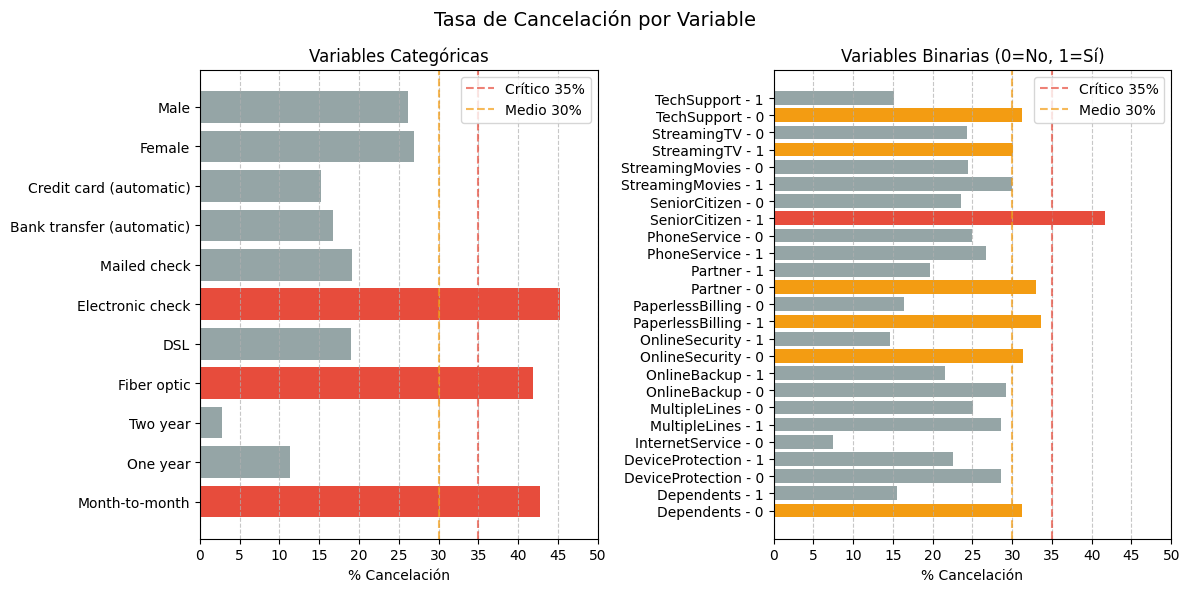

In [760]:
import matplotlib.pyplot as plt
text_variables = ['gender', 'Contract', 'PaymentMethod', 'InternetService']
binary_variables = ['Partner', 'Dependents', 'SeniorCitizen', 'PhoneService',
                    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'PaperlessBilling']

import matplotlib.pyplot as plt

df_texto = df_evasion[~df_evasion['Valor'].isin([0, 1])]
df_binario = df_evasion[df_evasion['Valor'].isin([0, 1])].copy()
df_binario['Etiqueta'] = df_binario['Variable'] + ' - ' + df_binario['Valor'].astype(str)

umbral_medio = 30
umbral_alto = 35

def asignar_color(valor):
    if valor >= umbral_alto:
        return '#e74c3c'
    elif valor >= umbral_medio:
        return '#f39c12'
    else:
        return '#95a5a6'

colores_texto = [asignar_color(v) for v in df_texto['% Cancelación']]
colores_binario = [asignar_color(v) for v in df_binario['% Cancelación']]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))


axes[0].barh(df_texto['Valor'], df_texto['% Cancelación'], color=colores_texto)
axes[0].set_title('Variables Categóricas')
axes[0].set_xlabel('% Cancelación')
axes[0].axvline(x=umbral_alto, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Crítico {umbral_alto}%')
axes[0].axvline(x=umbral_medio, color='#f39c12', linestyle='--', alpha=0.7, label=f'Medio {umbral_medio}%')
axes[0].grid(True, axis='x', linestyle='--', alpha=0.7)
axes[0].set_xlim(0, 50)
axes[0].set_xticks(range(0, 51, 5))
axes[0].legend(loc='upper right')


axes[1].barh(df_binario['Etiqueta'], df_binario['% Cancelación'], color=colores_binario)
axes[1].set_title('Variables Binarias (0=No, 1=Sí)')
axes[1].set_xlabel('% Cancelación')
axes[1].axvline(x=umbral_alto, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Crítico {umbral_alto}%')
axes[1].axvline(x=umbral_medio, color='#f39c12', linestyle='--', alpha=0.7, label=f'Medio {umbral_medio}%')
axes[1].grid(True, axis='x', linestyle='--', alpha=0.7)
axes[1].set_xlim(0, 50)
axes[1].set_xticks(range(0, 51, 5))
axes[1].legend(loc='upper right')

plt.suptitle('Tasa de Cancelación por Variable', fontsize=14)
plt.tight_layout()
plt.savefig('02_variables_categoricas.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [753]:
df.groupby('InternetService')['Charges.Monthly'].mean()

,Charges.Monthly
InternetService,
0,21.079194
DSL,58.102169
Fiber optic,91.500129


###**INSIGHTS**
**Del 25.6% de los clientes que cancelaron el servicio**

**INSIGHTS - NIVEL CRÍTICO (≥35% cancelación)**

**1. Electronic check (45.29%)**
El método de pago con cheque electrónico es el más riesgoso. Casi la mitad de los clientes que usan este método cancelan el servicio. A diferencia de los pagos automáticos con tarjeta o banco, el cheque electrónico requiere acción manual del cliente, lo que facilita la decisión de cancelar.

**2. Month-to-month (42.71%)**
Los contratos mensuales presentan la mayor tasa de cancelación por tipo de contrato. Sin compromiso a largo plazo, los clientes pueden irse en cualquier momento sin penalización.

**3. Fiber optic (41.89%)**
Los clientes con fibra óptica cancelan más que los de DSL (18.96%). Esto podría indicar insatisfacción con el servicio, problemas técnicos frecuentes, o precios más altos que no justifican el valor percibido.

**4. SeniorCitizen - 1 (41.68%)**
Los adultos mayores cancelan casi el doble que los no adultos mayores (23.61%). Posibles causas: dificultad para usar el servicio.

---

**INSIGHTS - NIVEL MEDIO (30-34% cancelación)**

**1. PaperlessBilling - 1 (33.57%)**
Clientes con facturación digital cancelan más que los que reciben factura física (16.33%). La facturación electrónica reduce el contacto humano y los recordatorios físicos del servicio. Lo mismo que sucede con **Electronic check**.

**2. Partner - 0 (32.96%)**
Clientes sin pareja cancelan más que los que tienen pareja (19.66%). Las personas solas pueden tener menos estabilidad o compromiso con servicios a largo plazo.

**3. OnlineSecurity - 0 (31.33%)**
Clientes sin servicio de seguridad online cancelan más del doble que los que sí lo tienen (14.61%). Este servicio adicional genera mayor "atadura" al proveedor.

**4. Dependents - 0 (31.28%)**
Clientes sin dependientes cancelan el doble que los que tienen familia (15.45%). Las familias buscan estabilidad y evitan cambios en servicios del hogar.

**5. TechSupport - 0 (31.19%)**
Sin soporte técnico, los clientes cancelan más del doble que los que sí lo tienen (15.17%). El soporte técnico aumenta la satisfacción y resuelve problemas antes de que el cliente decida irse.

**6. StreamingTV - 1 (30.07%)**
Curiosamente, los que tienen StreamingTV cancelan ligeramente más. Podría indicar que buscan alternativas de streaming externas o que el costo adicional no justifica el valor.


##**Conteo de evasión por variables numéricas**

###Explorar cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

In [754]:
cancelaron = df.groupby('Churn')[['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']].agg(['mean', 'median', 'std']).round(2)
cancelaron.index = ['Se quedaron', 'Cancelaron']
cancelaron

tenure               Charges.Monthly               Charges.Total  \
              mean median    std            mean median    std          mean   
Se quedaron  37.57   38.0  24.11           61.27  64.43  31.09       2549.91   
Cancelaron   17.98   10.0  19.53           74.44  79.65  24.67       1531.80   

                              Cuentas_Diarias               
              median      std            mean median   std  
Se quedaron  1679.52  2329.95            2.04   2.15  1.04  
Cancelaron    703.55  1890.82            2.48   2.66  0.82

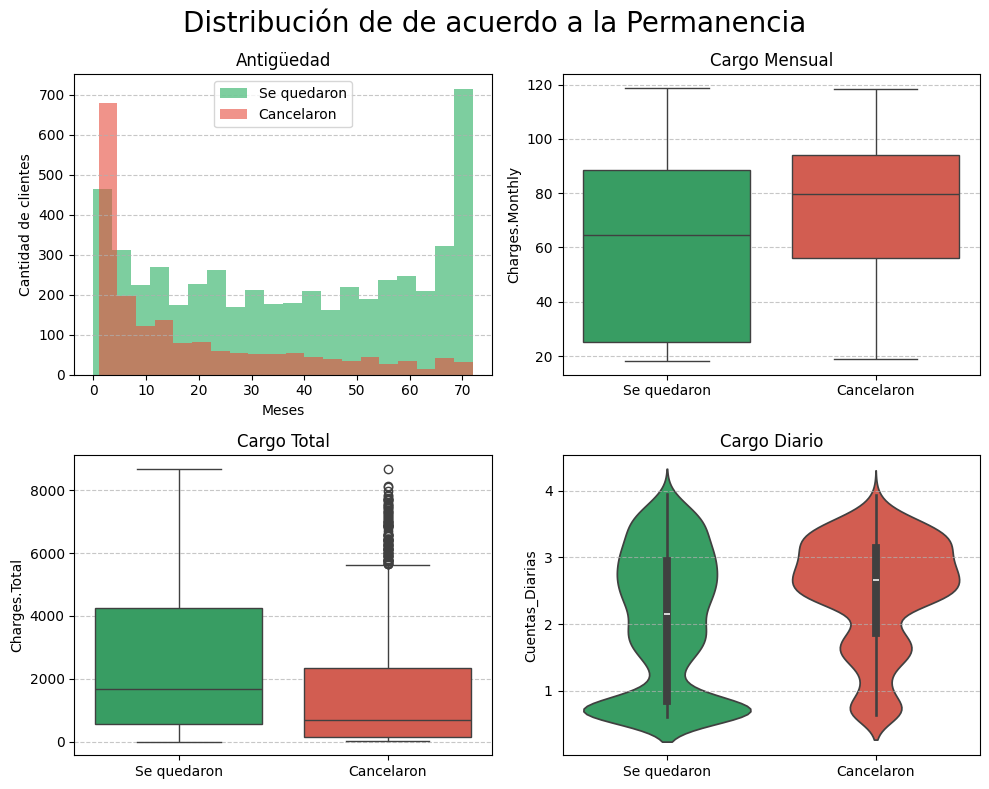

In [761]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(df[df['Churn'] == 0]['tenure'], alpha=0.6, label='Se quedaron', color='#27AE60',bins=20)
axes[0, 0].hist(df[df['Churn'] == 1]['tenure'], alpha=0.6, label='Cancelaron', color='#E74C3C', bins=20)
axes[0, 0].set_title('Antigüedad')
axes[0, 0].set_xlabel('Meses')
axes[0, 0].set_ylabel('Cantidad de clientes')
axes[0, 0].legend()
axes[0, 0].grid(True, axis='y', linestyle='--', alpha=0.7)

sns.boxplot(data=df, x='Churn', y='Charges.Monthly', ax=axes[0, 1], palette={0: '#27AE60', 1: '#E74C3C'}, hue='Churn', legend=False)
axes[0, 1].set_title('Cargo Mensual')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Se quedaron', 'Cancelaron'])
axes[0, 1].set_xlabel('')
axes[0, 1].grid(True, axis='y', linestyle='--', alpha=0.7)


sns.boxplot(data=df, x='Churn', y='Charges.Total', ax=axes[1, 0], palette={0: '#27AE60', 1: '#E74C3C'}, hue='Churn', legend=False)
axes[1, 0].set_title('Cargo Total')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Se quedaron', 'Cancelaron'])
axes[1, 0].set_xlabel('')
axes[1, 0].grid(True, axis='y', linestyle='--', alpha=0.7)

sns.violinplot(data=df, x='Churn', y='Cuentas_Diarias', ax=axes[1, 1], palette={0: '#27AE60', 1: '#E74C3C'}, hue='Churn', legend=False)
axes[1, 1].set_title('Cargo Diario')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Se quedaron', 'Cancelaron'])
axes[1, 1].set_xlabel('')
axes[1, 1].grid(True, axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Distribución de de acuerdo a la Permanencia', fontsize=20)
plt.tight_layout()
plt.savefig('03_distribucion_numerica.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

In [756]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [757]:
df[df['Charges.Total'] == 8684.80]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
2053,2889-FPWRM,1,Male,0,1,0,72,1,1,Fiber optic,1,1,1,1,1,1,One year,1,Bank transfer (automatic),117.8,8684.8,3.926667


### **INSIGHTS**
####DISTRIBUCIÓN DE VARIABLES NUMÉRICAS POR TASA DE CANCELACION

**1. ANTIGÜEDAD**

La fuga de clientes ocurre principalmente en los primeros meses de contrato. El histograma muestra una concentración alta de cancelaciones (rojo) entre 0-10 meses, mientras que los clientes que permanecen (verde) se distribuyen más uniformemente y muchos llegan hasta los 70 meses. Si un cliente sobrevive el primer año, es muy probable que se mantenga fiel.

**2. CARGO MENSUAL**

Los clientes que cancelan pagan más por mes. La mediana de los que cancelan (USD 80) es mayor que la de los que se quedan (USD 65). La caja roja está más arriba y más compacta, indicando que los planes caros generan mayor insatisfacción.

**3. CARGO TOTAL (Charges.Total)**

Los clientes que cancelan acumulan menos gasto total. Su mediana (USD 700) es menos de la mitad que la de los que permanecen (USD 1,700). Los outliers (puntos) están en el grupo rojo, representando clientes que cancelaron a pesar de haber acumulado un gasto alto (USD 5,000-USD 8,000), lo cual indica insatisfacción severa incluso en clientes de largo plazo.

**4. CARGO DIARIO (Cuentas_Diarias)**

El violinplot muestra que los clientes que cancelan (rojo) tienen cargos diarios concentrados en valores altos (USD 2.50- USD 3.00), con forma más angosta arriba. Los que permanecen (verde) tienen distribución más amplia con concentración en valores bajos (USD 1.00), visible por el ensanchamiento del violín abajo.

**CONCLUSIÓN GENERAL:**

Los clientes que cancelan pagan más (mensual y diariamente) pero duran menos tiempo. El precio alto sin suficiente tiempo para percibir valor genera insatisfacción y fuga temprana. La estrategia de retención debe enfocarse en los primeros 12 meses y en clientes con planes de alto costo.

##**Correlacion**

Explorar la correlación entre diferentes variables del dataset. Esto puede ayudar a identificar qué factores tienen mayor relación con la evasión de clientes, como:

🔹 La relación entre la cuenta diaria y la evasión.

🔹 Cómo la cantidad de servicios contratados afecta la probabilidad de churn.



In [758]:
servicios = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['Cantidad_Servicios'] = df[servicios].sum(axis=1)

correlacion= df[['Churn', 'Cuentas_Diarias', 'Cantidad_Servicios']].corr()
correlacion

,Churn,Cuentas_Diarias,Cantidad_Servicios
Churn,1.000000,0.193356,-0.067264
Cuentas_Diarias,0.193356,1.000000,0.802322
Cantidad_Servicios,-0.067264,0.802322,1.000000


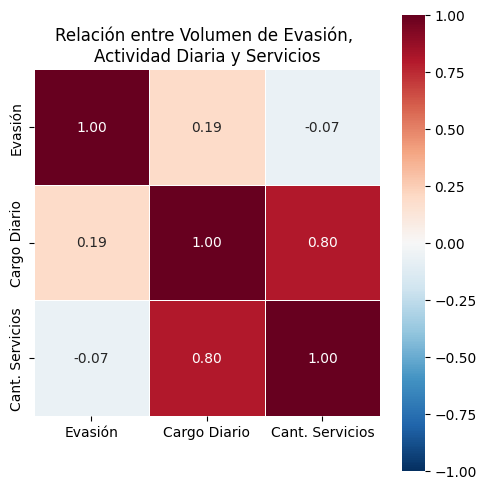

In [762]:
import matplotlib.pyplot as plt
import seaborn as sns

correlacion = df[['Churn', 'Cuentas_Diarias', 'Cantidad_Servicios']].corr()

plt.figure(figsize=(5, 5))
sns.heatmap(correlacion, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.5, square=True, vmin=-1, vmax=1,
            xticklabels=['Evasión', 'Cargo Diario', 'Cant. Servicios'],
            yticklabels=['Evasión', 'Cargo Diario', 'Cant. Servicios'])
plt.title('Relación entre Volumen de Evasión, \nActividad Diaria y Servicios')
plt.tight_layout()
plt.savefig('04_correlacion.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

##**INSIGHTS**

**1. Cuentas Diarias vs Churn (correlación: +0.19)**

Existe una correlación positiva débil entre el cargo diario y la cancelación. Los clientes que pagan más por día tienen una ligera tendencia a cancelar el servicio. Sin embargo, esta relación no es determinante por sí sola, lo que indica que el precio es un factor de riesgo pero no el único.

**2. Cantidad de Servicios vs Churn (correlación: -0.07)**

La cantidad de servicios contratados tiene una correlación casi nula con el churn. Esto significa que contratar más servicios no aumenta ni reduce significativamente la probabilidad de cancelar.

**3. Cuentas Diarias vs Cantidad de Servicios (correlación: +0.80)**

Existe una correlación positiva fuerte entre estas variables. Es lógico: más servicios contratados implica mayor costo diario.

**La Paradoja del Valor Percibido:**

Los datos revelan algo interesante: aunque más servicios significan mayor costo (+0.80), y mayor costo se asocia con más cancelaciones (+0.19), tener más servicios NO aumenta la tasa de cancelación (-0.07).

Esto sugiere que los servicios adicionales agregan valor percibido que compensa el costo alto. Un cliente que paga $3 diarios por múltiples servicios está más satisfecho que uno que paga lo mismo por un solo servicio.

**Conclusión:**

El factor crítico no es cuánto paga el cliente, sino qué recibe a cambio. La estrategia de retención debería enfocarse en aumentar el valor percibido, no solo en reducir precios.

#📄Informe final

# INFORME DE ANÁLISIS DE CHURN - TELECOMUNICACIONES

---

## 1. INTRODUCCIÓN

### Objetivo del Análisis
Analizar el comportamiento de los clientes de una empresa de telecomunicaciones para identificar los factores que influyen en la evasión (Churn) y proporcionar insights accionables para reducir la tasa de cancelación.

### El Problema del Churn
El Churn representa la pérdida de clientes que cancelan sus servicios. En telecomunicaciones, adquirir un nuevo cliente cuesta entre 5 y 25 veces más que retener uno existente, lo que hace crítico entender por qué los clientes se van y cómo prevenirlo.

### Dataset
Se trabajó con un dataset de 7,267 registros de clientes que incluye información demográfica, servicios contratados, facturación y estado de cancelación.


---

## 2. LIMPIEZA Y TRATAMIENTO DE DATOS

### 2.1 Importación de Datos
- Carga del archivo JSON con estructura anidada
- Aplanamiento de columnas usando `pd.json_normalize()`

### 2.2 Identificación de Problemas
Se detectaron los siguientes problemas en los datos:
- **Churn:** 224 valores vacíos (clientes sin información de estado)
- **Charges.Total:** 11 valores vacíos (clientes nuevos con tenure=0)

### 2.3 Tratamiento Aplicado

| Columna | Problema | Solución |
|---------|----------|----------|
| Churn | 224 valores vacíos | Eliminación de registros (no se puede asumir el estado) |
| Charges.Total | 11 valores vacíos | Cálculo con fórmula: Charges.Monthly × tenure |

### 2.4 Transformaciones
- Conversión de valores Yes/No a 1/0 para análisis numérico
- Reemplazo de "No internet service" y "No phone service" por "No"
- Creación de columna `Cuentas_Diarias` = Charges.Monthly / 30
- Creación de columna `Cantidad_Servicios` = suma de servicios contratados

### 2.5 Resultado Final
- **Registros originales:** 7,267
- **Registros limpios:** 7,043
- **Registros descartados:** 224 (3.1%)

---

## 3. ANÁLISIS EXPLORATORIO DE DATOS

### 3.1 Distribución General del Churn

In [764]:
# @title
import plotly.express as px

churn = df['Churn'].value_counts()

fig = px.pie(
    values=churn.values,
    names=['Se quedaron', 'Cancelaron'],
    title='Distribución de la Fidelidad de Clientes',
    color_discrete_sequence=['#27AE60', '#C0392B'],
    hole=0.3,
    width=600,
    height=500
)

fig.update_traces(
    textinfo='percent',
    textposition='inside',
    textfont_size=18,
    textfont_color='white',
    pull=[0, 0.05],
    marker_line_color='white',
    marker_line_width=5,
    hovertemplate='<b>%{label}</b><br>Clientes: %{value:,}<br>Porcentaje: %{percent}<extra></extra>'
)

fig.update_layout(
    title_x=0.5,
    title_font_size=24,
    title_font_color='#2C3E50',
    legend_orientation='h',
    legend_y=-0.1,
    legend_x=0.1,
    legend_font_size=20,
    font_family='Arial',
    paper_bgcolor='white'
)

fig.show()

**Hallazgo Principal:** El 26.5% de los clientes cancelaron el servicio (1,869 de 7,043). Esto significa que aproximadamente 1 de cada 4 clientes se va, lo cual representa una señal de alerta significativa para el negocio.

---

### 3.2 Análisis de Variables Categóricas

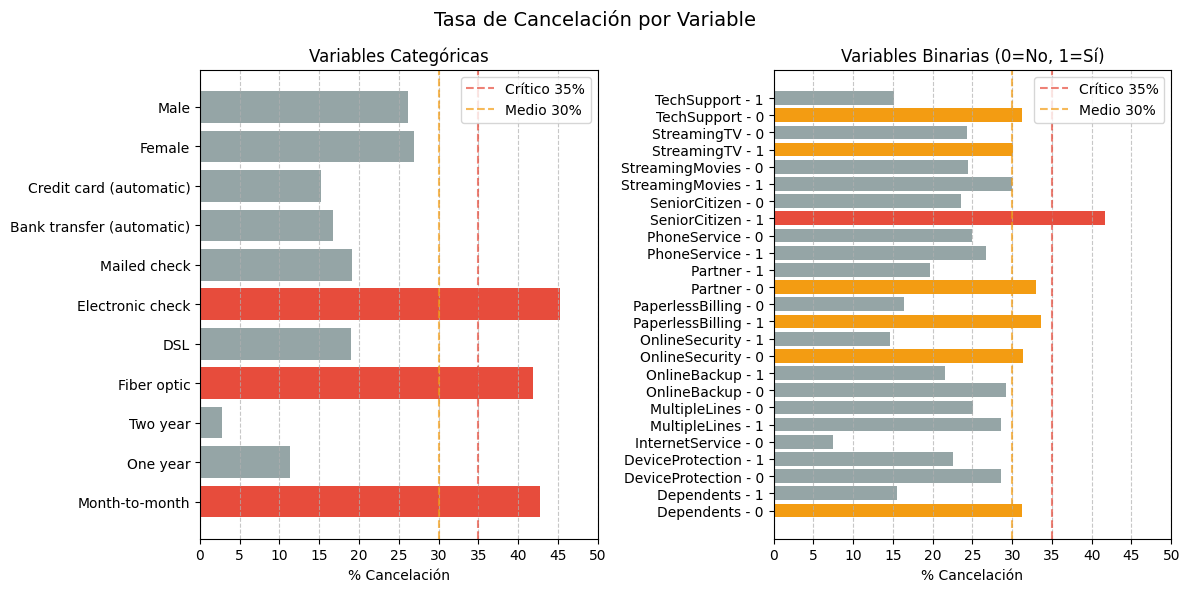

In [765]:
# @title
import matplotlib.pyplot as plt

df_texto = df_evasion[~df_evasion['Valor'].isin([0, 1])]
df_binario = df_evasion[df_evasion['Valor'].isin([0, 1])].copy()
df_binario['Etiqueta'] = df_binario['Variable'] + ' - ' + df_binario['Valor'].astype(str)

umbral_medio = 30
umbral_alto = 35

def asignar_color(valor):
    if valor >= umbral_alto:
        return '#e74c3c'
    elif valor >= umbral_medio:
        return '#f39c12'
    else:
        return '#95a5a6'

colores_texto = [asignar_color(v) for v in df_texto['% Cancelación']]
colores_binario = [asignar_color(v) for v in df_binario['% Cancelación']]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].barh(df_texto['Valor'], df_texto['% Cancelación'], color=colores_texto)
axes[0].set_title('Variables Categóricas')
axes[0].set_xlabel('% Cancelación')
axes[0].axvline(x=umbral_alto, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Crítico {umbral_alto}%')
axes[0].axvline(x=umbral_medio, color='#f39c12', linestyle='--', alpha=0.7, label=f'Medio {umbral_medio}%')
axes[0].grid(True, axis='x', linestyle='--', alpha=0.7)
axes[0].set_xlim(0, 50)
axes[0].set_xticks(range(0, 51, 5))
axes[0].legend(loc='upper right')

axes[1].barh(df_binario['Etiqueta'], df_binario['% Cancelación'], color=colores_binario)
axes[1].set_title('Variables Binarias (0=No, 1=Sí)')
axes[1].set_xlabel('% Cancelación')
axes[1].axvline(x=umbral_alto, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Crítico {umbral_alto}%')
axes[1].axvline(x=umbral_medio, color='#f39c12', linestyle='--', alpha=0.7, label=f'Medio {umbral_medio}%')
axes[1].grid(True, axis='x', linestyle='--', alpha=0.7)
axes[1].set_xlim(0, 50)
axes[1].set_xticks(range(0, 51, 5))
axes[1].legend(loc='upper right')

plt.suptitle('Tasa de Cancelación por Variable', fontsize=14)
plt.tight_layout()
plt.show()

#### Variables con Nivel Crítico de Churn (≥35% - Rojo)

| Variable | Valor | % Cancelación | Insight |
|----------|-------|---------------|---------|
| Método de Pago | Cheque electrónico | 45.29% | Método más riesgoso, casi la mitad cancela |
| Contrato | Mes a mes | 42.71% | Sin compromiso, fácil de cancelar |
| Servicio de Internet | Fibra óptica | 41.89% | Posible insatisfacción con servicio/precio |
| Adulto Mayor | Sí (1) | 41.68% | Segmento que requiere atención especial |

#### Variables con Nivel Medio de Churn (30-34% - Amarillo)

| Variable | Valor | % Cancelación | Insight |
|----------|-------|---------------|---------|
| Facturación Digital | Sí (1) | 33.57% | Menos contacto humano |
| Pareja | No (0) | 32.96% | Clientes solos menos estables |
| Seguridad en Línea | No (0) | 31.33% | Sin protección = menos atadura |
| Dependientes | No (0) | 31.28% | Sin familia = menos compromiso |
| Soporte Técnico | No (0) | 31.19% | Sin soporte = mayor insatisfacción |

#### Variables Estables (bajo % de cancelación - Gris)

| Variable | Valor | % Cancelación |
|----------|-------|---------------|
| Contrato | Dos años | 2.83% |
| Servicio de Internet | No | 7.40% |
| Contrato | Un año | 11.27% |

---

### 3.3 Análisis de Variables Numéricas

#### Comparativa por Estado de Churn


In [769]:
# @title
import pandas as pd

comparativa = pd.DataFrame({
    'Variable': ['Antigüedad (meses)', 'Cargo Mensual', 'Cargo Total', 'Cargo Diario'],
    'Se quedaron': [37.6, '$61.3', '$2,549', '$2.04'],
    'Cancelaron': [17.9, '$74.4', '$1,531', '$2.48'],
    'Diferencia': ['-19.7 meses', '+$13.1', '-$1,018', '+$0.44']
})

comparativa

,Variable,Se quedaron,Cancelaron,Diferencia
0,Antigüedad (meses),37.6,17.9,-19.7 meses
1,Cargo Mensual,$61.3,$74.4,+$13.1
2,Cargo Total,"$2,549","$1,531","-$1,018"
3,Cargo Diario,$2.04,$2.48,+$0.44


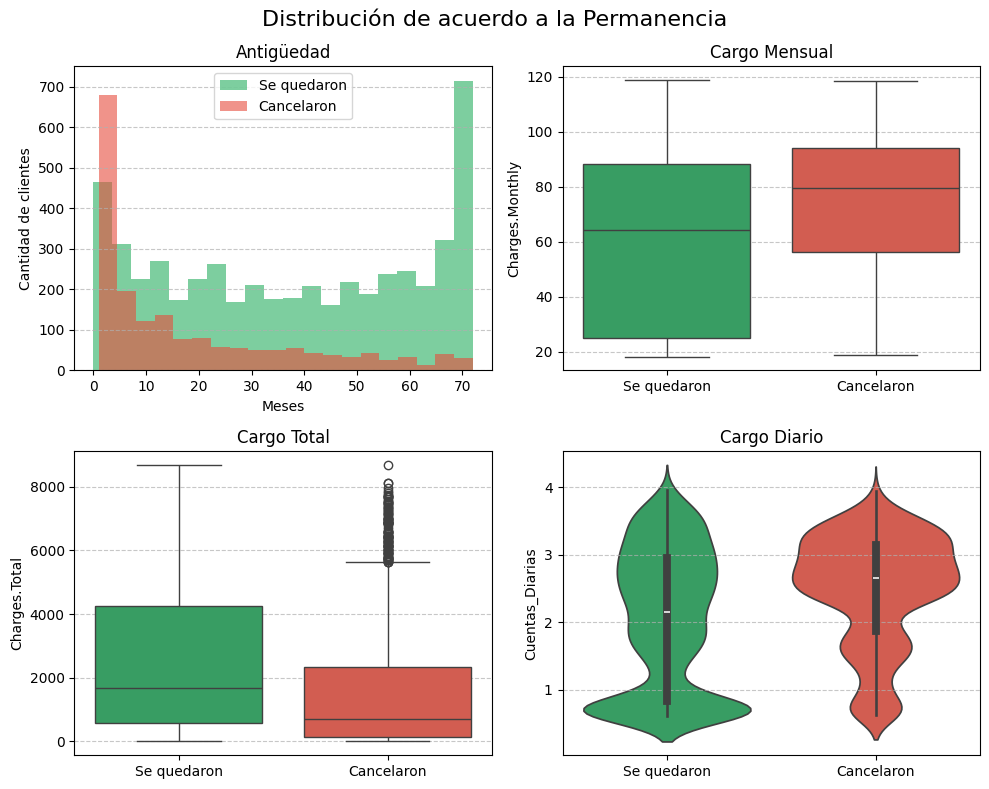

In [766]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(df[df['Churn'] == 0]['tenure'], alpha=0.6, label='Se quedaron', color='#27AE60', bins=20)
axes[0, 0].hist(df[df['Churn'] == 1]['tenure'], alpha=0.6, label='Cancelaron', color='#E74C3C', bins=20)
axes[0, 0].set_title('Antigüedad')
axes[0, 0].set_xlabel('Meses')
axes[0, 0].set_ylabel('Cantidad de clientes')
axes[0, 0].legend()
axes[0, 0].grid(True, axis='y', linestyle='--', alpha=0.7)

sns.boxplot(data=df, x='Churn', y='Charges.Monthly', ax=axes[0, 1], palette={0: '#27AE60', 1: '#E74C3C'}, hue='Churn', legend=False)
axes[0, 1].set_title('Cargo Mensual')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Se quedaron', 'Cancelaron'])
axes[0, 1].set_xlabel('')
axes[0, 1].grid(True, axis='y', linestyle='--', alpha=0.7)

sns.boxplot(data=df, x='Churn', y='Charges.Total', ax=axes[1, 0], palette={0: '#27AE60', 1: '#E74C3C'}, hue='Churn', legend=False)
axes[1, 0].set_title('Cargo Total')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Se quedaron', 'Cancelaron'])
axes[1, 0].set_xlabel('')
axes[1, 0].grid(True, axis='y', linestyle='--', alpha=0.7)

sns.violinplot(data=df, x='Churn', y='Cuentas_Diarias', ax=axes[1, 1], palette={0: '#27AE60', 1: '#E74C3C'}, hue='Churn', legend=False)
axes[1, 1].set_title('Cargo Diario')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Se quedaron', 'Cancelaron'])
axes[1, 1].set_xlabel('')
axes[1, 1].grid(True, axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Distribución de acuerdo a la Permanencia', fontsize=16)
plt.tight_layout()
plt.show()

#### Interpretación de los Gráficos

**1. Antigüedad (Histograma)**

La fuga de clientes ocurre principalmente en los primeros meses de contrato. El histograma muestra una concentración alta de cancelaciones (rojo) entre 0-10 meses, mientras que los clientes que permanecen (verde) se distribuyen más uniformemente y muchos llegan hasta los 70 meses. Si un cliente sobrevive el primer año, es muy probable que se mantenga fiel.

**2. Cargo Mensual (Boxplot)**

Los clientes que cancelan pagan más por mes. La mediana de los que cancelan (USD 80) es mayor que la de los que se quedan (USD 65). La caja roja está más arriba y más compacta, indicando que los planes caros generan mayor insatisfacción.

**3. Cargo Total (Boxplot)**

Los clientes que cancelan acumulan menos gasto total. Su mediana (USD 700) es menos de la mitad que la de los que permanecen (USD 1,700). Los outliers (puntos) están en el grupo rojo, representando clientes que cancelaron a pesar de haber acumulado un gasto alto (USD 5,000- USD 8,000), lo cual indica insatisfacción severa incluso en clientes de largo plazo.

**4. Cargo Diario (Violinplot)**

El violinplot muestra que los clientes que cancelan (rojo) tienen cargos diarios concentrados en valores altos (USD 2.50- USD 3.00), con forma más angosta arriba. Los que permanecen (verde) tienen distribución más amplia con concentración en valores bajos (USD 1.00), visible por el ensanchamiento del violín abajo.

---

### 3.4 Análisis de Correlación

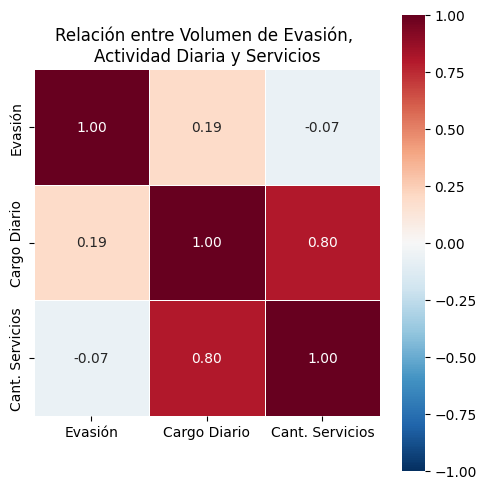

In [767]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

correlacion = df[['Churn', 'Cuentas_Diarias', 'Cantidad_Servicios']].corr()

plt.figure(figsize=(5, 5))
sns.heatmap(correlacion, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            linewidths=0.5, square=True, vmin=-1, vmax=1,
            xticklabels=['Evasión', 'Cargo Diario', 'Cant. Servicios'],
            yticklabels=['Evasión', 'Cargo Diario', 'Cant. Servicios'])
plt.title('Relación entre Volumen de Evasión, \nActividad Diaria y Servicios')
plt.tight_layout()
plt.show()

#### Interpretación de la Correlación

| Variables | Correlación | Interpretación |
|-----------|-------------|----------------|
| Evasión vs Cargo Diario | +0.19 | Mayor cargo diario = ligeramente más evasión |
| Evasión vs Cant. Servicios | -0.07 | Más servicios = ligeramente menos evasión |
| Cargo Diario vs Cant. Servicios | +0.80 | Más servicios = mayor costo (lógico) |

**La Paradoja del Valor Percibido:**

Los datos revelan algo interesante: aunque más servicios significan mayor costo (+0.80), y mayor costo se asocia con más cancelaciones (+0.19), tener más servicios NO aumenta la evasión (-0.07).

Esto sugiere que los servicios adicionales agregan valor percibido que compensa el costo alto. Un cliente que paga $3 diarios por múltiples servicios está más satisfecho que uno que paga lo mismo por un solo servicio.

**Conclusión:** El factor crítico no es cuánto paga el cliente, sino qué recibe a cambio.

---

## 4. CONCLUSIONES E INSIGHTS

### Perfil del Cliente de Alto Riesgo
- Contrato mes a mes
- Paga con cheque electrónico
- Tiene servicio de fibra óptica
- Es adulto mayor
- Sin pareja ni dependientes
- Sin servicios de protección (Seguridad en Línea, Soporte Técnico)
- Paga más de $70 mensuales
- Lleva menos de 12 meses como cliente

### Perfil del Cliente Estable
- Contrato de 1-2 años
- Pago automático (tarjeta o banco)
- Con pareja y/o dependientes
- Con servicios adicionales de protección
- Más de 12 meses de antigüedad

### Hallazgos Clave

1. **El primer año es crítico:** La mayoría de cancelaciones ocurren en los primeros 12 meses.

2. **El precio importa, pero no es todo:** Los que cancelan pagan más, pero el valor percibido (servicios adicionales) puede compensar.

3. **El compromiso retiene:** Contratos de 2 años tienen solo 2.83% de evasión vs 42.71% en mensuales.

4. **El método de pago predice riesgo:** Cheque electrónico tiene 45.29% de evasión vs 15-17% en pagos automáticos.

5. **Los servicios de protección generan lealtad:** Clientes con Seguridad en Línea y Soporte Técnico cancelan menos de la mitad que los que no los tienen.

---

## 5. RECOMENDACIONES ESTRATÉGICAS

### 5.1 Retención en Primeros 12 Meses
- Implementar programa de bienvenida con seguimiento personalizado
- Ofrecer descuentos o beneficios exclusivos para nuevos clientes durante el primer año
- Contacto proactivo al mes 3, 6 y 9 para evaluar satisfacción

### 5.2 Migración de Método de Pago
- Incentivar cambio de cheque electrónico a pago automático con descuentos
- Simplificar proceso de cambio de método de pago

### 5.3 Promoción de Contratos Largos
- Ofrecer descuentos significativos por contratos anuales o bianuales
- Crear paquetes atractivos que justifiquen el compromiso
- Mostrar ahorro total al comparar contrato mensual vs anual

### 5.4 Venta de Servicios de Protección
- Incluir Seguridad en Línea o Soporte Técnico gratis por 3 meses
- Crear paquetes de servicios con precio atractivo

### 5.5 Atención a Segmentos Vulnerables
- Programa especial para adultos mayores con soporte dedicado
- Planes simplificados y más económicos para clientes sensibles al precio
- Capacitación al equipo de soporte para atención a este segmento

### 5.6 Revisión del Servicio de Fibra Óptica
- Investigar causas de insatisfacción (precio, calidad, expectativas)
- Evaluar relación precio-valor comparado con DSL
- Mejorar soporte técnico específico para fibra

